In [ ]:
import os, pickle, shutil
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from google.colab import drive

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/movie_rec_project'
ML_DIR      = f'{PROJECT_DIR}/data/ml-1m'
TMD_DIR     = f'{PROJECT_DIR}/data/the_movies_dataset'
KAGGLE_DIR  = f'{PROJECT_DIR}/.kaggle'

for d in [PROJECT_DIR, ML_DIR, TMD_DIR, KAGGLE_DIR]:
    os.makedirs(d, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
if not os.path.exists(f'{ML_DIR}/ratings.dat'):
    !wget -q https://files.grouplens.org/datasets/movielens/ml-1m.zip -O /tmp/ml-1m.zip
    !unzip -q /tmp/ml-1m.zip -d {PROJECT_DIR}/data

print("MovieLens 1M ready.")

MovieLens 1M ready.


In [ ]:
token_path = f'{KAGGLE_DIR}/access_token'

if os.path.exists(token_path):
    with open(token_path) as f:
        os.environ['KAGGLE_API_TOKEN'] = f.read().strip()
else:
    token = input("Paste your Kaggle API token: ").strip()
    with open(token_path, 'w') as f:
        f.write(token)
    os.environ['KAGGLE_API_TOKEN'] = token

if not os.path.exists(f'{TMD_DIR}/movies_metadata.csv'):
    !pip install -q --upgrade "kagglehub>=0.4.1"
    import kagglehub
    src = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), TMD_DIR)

print("The Movies Dataset ready.")

The Movies Dataset ready.


In [ ]:
ratings = pd.read_csv(f'{ML_DIR}/ratings.dat', sep='::', engine='python', encoding='latin-1',
                     names=['user_id', 'movie_id', 'rating', 'timestamp'])

movies = pd.read_csv(f'{ML_DIR}/movies.dat', sep='::', engine='python', encoding='latin-1',
                    names=['movie_id', 'title', 'genres'])

meta  = pd.read_csv(f'{TMD_DIR}/movies_metadata.csv', low_memory=False)
links = pd.read_csv(f'{TMD_DIR}/links.csv')

print(f"Ratings: {len(ratings):,}   Movies: {len(movies):,}   Meta: {len(meta):,}")

Ratings: 1,000,209   Movies: 3,883   Meta: 45,466


In [ ]:
meta = meta[['id', 'overview']].dropna()
meta = meta[meta['id'].str.isdigit()]
meta['tmdbId'] = meta['id'].astype(int)
meta = meta[['tmdbId', 'overview']]

links = links.dropna(subset=['tmdbId'])
links['tmdbId'] = links['tmdbId'].astype(int)

movies = (movies
          .merge(links[['movieId', 'tmdbId']], left_on='movie_id', right_on='movieId')
          .merge(meta, on='tmdbId')
          .drop_duplicates(subset='movie_id'))

ratings = ratings[ratings['movie_id'].isin(movies['movie_id'])].reset_index(drop=True)

print(f"Movies with plots: {len(movies):,}")
print(f"Ratings retained:  {len(ratings):,}")

Movies with plots: 3,810
Ratings retained:  997,313


In [ ]:
user2idx  = {u: i for i, u in enumerate(ratings['user_id'].unique())}
movie2idx = {m: i for i, m in enumerate(ratings['movie_id'].unique())}

ratings['u_idx'] = ratings['user_id'].map(user2idx)
ratings['m_idx'] = ratings['movie_id'].map(movie2idx)

NUM_USERS  = len(user2idx)
NUM_MOVIES = len(movie2idx)

train_df, temp_df = train_test_split(ratings, test_size=0.2, random_state=SEED, stratify=ratings['u_idx'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['u_idx'])

print(f"Users: {NUM_USERS:,}   Movies: {NUM_MOVIES:,}")
print(f"Train: {len(train_df):,}   Val: {len(val_df):,}   Test: {len(test_df):,}")

Users: 6,040   Movies: 3,657
Train: 797,850   Val: 99,731   Test: 99,732


In [ ]:
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.m = torch.tensor(df['m_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.m[idx], self.r[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(MovieLensDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MovieLensDataset(val_df),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(MovieLensDataset(test_df),  batch_size=BATCH_SIZE)

u, m, r = next(iter(train_loader))
print(f"Batch shapes — users: {u.shape}, movies: {m.shape}, ratings: {r.shape}")

Batch shapes — users: torch.Size([1024]), movies: torch.Size([1024]), ratings: torch.Size([1024])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class NCF(nn.Module):
    def __init__(self, num_users, num_movies, emb_dim=64):
        super().__init__()
        self.user_emb  = nn.Embedding(num_users,  emb_dim)
        self.movie_emb = nn.Embedding(num_movies, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 64), nn.ReLU(),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, u, m):
        x = torch.cat([self.user_emb(u), self.movie_emb(m)], dim=1)
        return self.mlp(x).squeeze(-1)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Training on", device)

model = NCF(NUM_USERS, NUM_MOVIES, emb_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for u, m, r in train_loader:
        u, m, r = u.to(device), m.to(device), r.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(u, m), r)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(r)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_se = 0
    with torch.no_grad():
        for u, m, r in val_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            val_se += ((model(u, m) - r) ** 2).sum().item()
    val_rmse = (val_se / len(val_loader.dataset)) ** 0.5

    print(f"Epoch {epoch:2d}  train_mse={train_loss:.4f}  val_rmse={val_rmse:.4f}")

Training on cuda
Epoch  1  train_mse=1.5102  val_rmse=0.9758
Epoch  2  train_mse=0.8953  val_rmse=0.9380
Epoch  3  train_mse=0.8462  val_rmse=0.9276
Epoch  4  train_mse=0.8256  val_rmse=0.9222
Epoch  5  train_mse=0.8140  val_rmse=0.9212
Epoch  6  train_mse=0.8052  val_rmse=0.9207
Epoch  7  train_mse=0.7982  val_rmse=0.9203
Epoch  8  train_mse=0.7921  val_rmse=0.9192
Epoch  9  train_mse=0.7854  val_rmse=0.9201
Epoch 10  train_mse=0.7799  val_rmse=0.9194


In [ ]:
model.eval()
test_se = 0
with torch.no_grad():
    for u, m, r in test_loader:
        u, m, r = u.to(device), m.to(device), r.to(device)
        test_se += ((model(u, m) - r) ** 2).sum().item()
test_rmse = (test_se / len(test_loader.dataset)) ** 0.5

print(f"Branch 1 (NCF) test RMSE: {test_rmse:.4f}")

torch.save(model.state_dict(), f'{PROJECT_DIR}/branch1_ncf.pt')
print("Model saved to Drive.")

Branch 1 (NCF) test RMSE: 0.9171
Model saved to Drive.


In [ ]:
!pip install -q transformers

from transformers import AutoTokenizer, AutoModel

BERT_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert = AutoModel.from_pretrained(BERT_NAME).to(device).eval()

for p in bert.parameters():
    p.requires_grad = False

print("DistilBERT loaded — frozen, in eval mode.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded — frozen, in eval mode.


In [ ]:
PLOT_EMB_PATH = f'{PROJECT_DIR}/plot_embeddings.pt'

if os.path.exists(PLOT_EMB_PATH):
    plot_emb = torch.load(PLOT_EMB_PATH)
    print(f"Loaded cached plot embeddings: {plot_emb.shape}")
else:
    movie_plots = (movies.assign(m_idx=movies['movie_id'].map(movie2idx))
                          .dropna(subset=['m_idx'])
                          .drop_duplicates(subset='m_idx')       # <-- fix
                          .sort_values('m_idx'))
    assert len(movie_plots) == NUM_MOVIES

    plots = movie_plots['overview'].astype(str).tolist()

    plot_emb = torch.zeros(NUM_MOVIES, 768)
    BS = 32
    for i in range(0, len(plots), BS):
        batch = plots[i:i + BS]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            out = bert(**enc).last_hidden_state[:, 0, :]
        plot_emb[i:i + BS] = out.cpu()

    torch.save(plot_emb, PLOT_EMB_PATH)
    print(f"Extracted and saved: {plot_emb.shape}")

Loaded cached plot embeddings: torch.Size([3657, 768])


In [ ]:
class MovieLensTextDataset(Dataset):
    def __init__(self, df, plot_emb):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.m = torch.tensor(df['m_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float)
        self.plot_emb = plot_emb

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.m[idx], self.plot_emb[self.m[idx]], self.r[idx]


train_loader = DataLoader(MovieLensTextDataset(train_df, plot_emb), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MovieLensTextDataset(val_df,   plot_emb), batch_size=BATCH_SIZE)
test_loader  = DataLoader(MovieLensTextDataset(test_df,  plot_emb), batch_size=BATCH_SIZE)

u, m, p, r = next(iter(train_loader))
print(f"Batch — users: {u.shape}, movies: {m.shape}, plots: {p.shape}, ratings: {r.shape}")

Batch — users: torch.Size([1024]), movies: torch.Size([1024]), plots: torch.Size([1024, 768]), ratings: torch.Size([1024])


In [ ]:
class NCF_Text(nn.Module):
    def __init__(self, num_users, num_movies, emb_dim=64, plot_dim=768):
        super().__init__()
        self.user_emb  = nn.Embedding(num_users,  emb_dim)
        self.movie_emb = nn.Embedding(num_movies, emb_dim)
        self.plot_proj = nn.Linear(plot_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 3, 128), nn.ReLU(),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, u, m, p):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.plot_proj(p)], dim=1)
        return self.mlp(x).squeeze(-1)

In [ ]:
model2 = NCF_Text(NUM_USERS, NUM_MOVIES).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, EPOCHS + 1):
    model2.train()
    train_loss = 0
    for u, m, p, r in train_loader:
        u, m, p, r = u.to(device), m.to(device), p.to(device), r.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model2(u, m, p), r)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(r)
    train_loss /= len(train_loader.dataset)

    model2.eval()
    val_se = 0
    with torch.no_grad():
        for u, m, p, r in val_loader:
            u, m, p, r = u.to(device), m.to(device), p.to(device), r.to(device)
            val_se += ((model2(u, m, p) - r) ** 2).sum().item()
    val_rmse = (val_se / len(val_loader.dataset)) ** 0.5
    print(f"Epoch {epoch:2d}  train_mse={train_loss:.4f}  val_rmse={val_rmse:.4f}")

# Test
model2.eval()
test_se = 0
with torch.no_grad():
    for u, m, p, r in test_loader:
        u, m, p, r = u.to(device), m.to(device), p.to(device), r.to(device)
        test_se += ((model2(u, m, p) - r) ** 2).sum().item()
test_rmse2 = (test_se / len(test_loader.dataset)) ** 0.5

print(f"\nBranch 1 (NCF only):       {test_rmse:.4f}")
print(f"Branch 2 (NCF + plot text): {test_rmse2:.4f}")
print(f"Improvement: {test_rmse - test_rmse2:+.4f}")

torch.save(model2.state_dict(), f'{PROJECT_DIR}/branch2_ncf_text.pt')

Epoch  1  train_mse=1.1573  val_rmse=0.9507
Epoch  2  train_mse=0.8623  val_rmse=0.9221
Epoch  3  train_mse=0.8295  val_rmse=0.9210
Epoch  4  train_mse=0.8185  val_rmse=0.9235
Epoch  5  train_mse=0.8098  val_rmse=0.9124
Epoch  6  train_mse=0.8037  val_rmse=0.9084
Epoch  7  train_mse=0.7963  val_rmse=0.9121
Epoch  8  train_mse=0.7887  val_rmse=0.9107
Epoch  9  train_mse=0.7826  val_rmse=0.9071
Epoch 10  train_mse=0.7745  val_rmse=0.9047

Branch 1 (NCF only):       0.9171
Branch 2 (NCF + plot text): 0.9004
Improvement: +0.0167


In [ ]:
movies['genres_list'] = movies['genres'].str.split('|')
movies['year']        = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['decade']      = (movies['year'] // 10 * 10).astype('Int64').astype(str)

unique_movies  = sorted(movies['movie_id'].unique())
unique_genres  = sorted({g for gs in movies['genres_list'] for g in gs})
unique_decades = sorted(movies['decade'].dropna().unique())

entity_list = ([f"M_{m}" for m in unique_movies]
             + [f"G_{g}" for g in unique_genres]
             + [f"D_{d}" for d in unique_decades])
entity2idx = {e: i for i, e in enumerate(entity_list)}

NUM_ENTITIES, NUM_RELATIONS = len(entity_list), 2   # 0=has_genre, 1=in_decade

triples = []
for _, row in movies.iterrows():
    m_eid = entity2idx[f"M_{row['movie_id']}"]
    for g in row['genres_list']:
        triples.append((m_eid, 0, entity2idx[f"G_{g}"]))
    if pd.notna(row['decade']):
        triples.append((m_eid, 1, entity2idx[f"D_{row['decade']}"]))

triples = torch.tensor(triples, dtype=torch.long)
print(f"Triples: {len(triples):,}   Entities: {NUM_ENTITIES:,}   Relations: {NUM_RELATIONS}")

Triples: 10,125   Entities: 3,838   Relations: 2


In [ ]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, emb_dim=50):
        super().__init__()
        self.entity_emb   = nn.Embedding(num_entities,  emb_dim)
        self.relation_emb = nn.Embedding(num_relations, emb_dim)
        nn.init.xavier_uniform_(self.entity_emb.weight)
        nn.init.xavier_uniform_(self.relation_emb.weight)

    def score(self, h, r, t):
        return torch.norm(self.entity_emb(h) + self.relation_emb(r) - self.entity_emb(t), dim=1)

In [ ]:
KG_EMB_PATH = f'{PROJECT_DIR}/kg_embeddings.pt'
KG_DIM = 50

if os.path.exists(KG_EMB_PATH):
    kg_emb = torch.load(KG_EMB_PATH)
    print(f"Loaded cached KG embeddings: {kg_emb.shape}")
else:
    transe = TransE(NUM_ENTITIES, NUM_RELATIONS, emb_dim=KG_DIM).to(device)
    optimizer = torch.optim.Adam(transe.parameters(), lr=1e-3)
    triples_dev = triples.to(device)
    MARGIN, KG_BS = 1.0, 512

    for epoch in range(1, 51):
        perm = torch.randperm(len(triples_dev))
        total = 0
        for i in range(0, len(triples_dev), KG_BS):
            batch = triples_dev[perm[i:i + KG_BS]]
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            t_neg = torch.randint(0, NUM_ENTITIES, t.shape, device=device)

            pos = transe.score(h, r, t)
            neg = transe.score(h, r, t_neg)
            loss = F.relu(MARGIN + pos - neg).mean()

            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
        if epoch % 10 == 0:
            print(f"Epoch {epoch:2d}  loss={total / (len(triples_dev) // KG_BS + 1):.4f}")

    kg_emb = torch.zeros(NUM_MOVIES, KG_DIM)
    for mid, idx in movie2idx.items():
        kg_emb[idx] = transe.entity_emb.weight[entity2idx[f"M_{mid}"]].detach().cpu()

    torch.save(kg_emb, KG_EMB_PATH)
    print(f"Saved KG embeddings: {kg_emb.shape}")

Loaded cached KG embeddings: torch.Size([3657, 50])


In [ ]:
class MovieLensFullDataset(Dataset):
    def __init__(self, df, plot_emb, kg_emb):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.m = torch.tensor(df['m_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float)
        self.plot_emb = plot_emb
        self.kg_emb   = kg_emb

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.m[idx], self.plot_emb[self.m[idx]], self.kg_emb[self.m[idx]], self.r[idx]


train_loader = DataLoader(MovieLensFullDataset(train_df, plot_emb, kg_emb), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MovieLensFullDataset(val_df,   plot_emb, kg_emb), batch_size=BATCH_SIZE)
test_loader  = DataLoader(MovieLensFullDataset(test_df,  plot_emb, kg_emb), batch_size=BATCH_SIZE)

u, m, p, k, r = next(iter(train_loader))
print(f"Batch — u: {u.shape}, m: {m.shape}, p: {p.shape}, k: {k.shape}, r: {r.shape}")

Batch — u: torch.Size([1024]), m: torch.Size([1024]), p: torch.Size([1024, 768]), k: torch.Size([1024, 50]), r: torch.Size([1024])


In [ ]:
class NCF_Text_KG(nn.Module):
    def __init__(self, num_users, num_movies, emb_dim=64, plot_dim=768, kg_dim=50):
        super().__init__()
        self.user_emb  = nn.Embedding(num_users,  emb_dim)
        self.movie_emb = nn.Embedding(num_movies, emb_dim)
        self.plot_proj = nn.Linear(plot_dim, emb_dim)
        self.kg_proj   = nn.Linear(kg_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 4, 128), nn.ReLU(),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, u, m, p, k):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.plot_proj(p), self.kg_proj(k)], dim=1)
        return self.mlp(x).squeeze(-1)

In [ ]:
model3 = NCF_Text_KG(NUM_USERS, NUM_MOVIES).to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, EPOCHS + 1):
    model3.train()
    train_loss = 0
    for u, m, p, k, r in train_loader:
        u, m, p, k, r = u.to(device), m.to(device), p.to(device), k.to(device), r.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model3(u, m, p, k), r)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(r)
    train_loss /= len(train_loader.dataset)

    model3.eval()
    val_se = 0
    with torch.no_grad():
        for u, m, p, k, r in val_loader:
            u, m, p, k, r = u.to(device), m.to(device), p.to(device), k.to(device), r.to(device)
            val_se += ((model3(u, m, p, k) - r) ** 2).sum().item()
    val_rmse = (val_se / len(val_loader.dataset)) ** 0.5
    print(f"Epoch {epoch:2d}  train_mse={train_loss:.4f}  val_rmse={val_rmse:.4f}")

model3.eval()
test_se = 0
with torch.no_grad():
    for u, m, p, k, r in test_loader:
        u, m, p, k, r = u.to(device), m.to(device), p.to(device), k.to(device), r.to(device)
        test_se += ((model3(u, m, p, k) - r) ** 2).sum().item()
test_rmse3 = (test_se / len(test_loader.dataset)) ** 0.5

print(f"\nBranch 1 (NCF only):              {test_rmse:.4f}")
print(f"Branch 2 (NCF + text):            {test_rmse2:.4f}")
print(f"Branch 3 (NCF + text + KG):       {test_rmse3:.4f}")
print(f"Total improvement over baseline: {test_rmse - test_rmse3:+.4f}")

torch.save(model3.state_dict(), f'{PROJECT_DIR}/branch3_full.pt')

Epoch  1  train_mse=1.1587  val_rmse=0.9507
Epoch  2  train_mse=0.8566  val_rmse=0.9206
Epoch  3  train_mse=0.8270  val_rmse=0.9187
Epoch  4  train_mse=0.8170  val_rmse=0.9133
Epoch  5  train_mse=0.8117  val_rmse=0.9119
Epoch  6  train_mse=0.8048  val_rmse=0.9127
Epoch  7  train_mse=0.7974  val_rmse=0.9068
Epoch  8  train_mse=0.7910  val_rmse=0.9121
Epoch  9  train_mse=0.7818  val_rmse=0.9101
Epoch 10  train_mse=0.7751  val_rmse=0.9039

Branch 1 (NCF only):              0.9171
Branch 2 (NCF + text):            0.9004
Branch 3 (NCF + text + KG):       0.9005
Total improvement over baseline: +0.0166


In [ ]:
m_to_movieid = {v: k for k, v in movie2idx.items()}

def predict_rating(user_idx, movie_idx, plot_text=None):
    """Predict rating. If plot_text is given, re-encode it; else use cached plot_emb."""
    u = torch.tensor([user_idx], device=device)
    m = torch.tensor([movie_idx], device=device)
    k = kg_emb[movie_idx].unsqueeze(0).to(device)

    if plot_text is None:
        p = plot_emb[movie_idx].unsqueeze(0).to(device)
    else:
        enc = tokenizer([plot_text], padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            p = bert(**enc).last_hidden_state[:, 0, :]

    model3.eval()
    with torch.no_grad():
        return model3(u, m, p, k).item()


# Pick one example to explain throughout this section
sample_u, sample_m = 0, 0
sample_movie_id = m_to_movieid[sample_m]
sample_row      = movies[movies['movie_id'] == sample_movie_id].iloc[0]

print(f"User idx:  {sample_u}")
print(f"Movie:     {sample_row['title']}")
print(f"Plot:      {sample_row['overview'][:200]}...")
print(f"Predicted rating: {predict_rating(sample_u, sample_m):.3f}")

User idx:  0
Movie:     One Flew Over the Cuckoo's Nest (1975)
Plot:      While serving time for insanity at a state mental hospital, implacable rabble-rouser, Randle Patrick McMurphy inspires his fellow patients to rebel against the authoritarian rule of head nurse, Mildre...
Predicted rating: 4.803


In [ ]:
w!pip install -q lime
from lime.lime_text import LimeTextExplainer

def lime_predict_fn(texts):
    """LIME helper: predicts ratings for a list of plot strings."""
    res = []
    for t in texts:
        res.append(predict_rating(sample_u, sample_m, plot_text=t))
    # LIME expects (samples, num_classes) probabilities.
    # We'll map rating [1, 5] to a pseudo-probability for 'like'.
    preds = np.array(res)
    like_prob = (preds - 1) / 4.0
    return np.stack([1 - like_prob, like_prob], axis=1)

# Common English stopwords
STOPWORDS = set("""a an the and or but if then else when where which who what why how
                   in on at to for of by with from as is am are was were be been being
                   have has had do does did this that these those it its he she they we
                   his her their our my your""".split())

explainer = LimeTextExplainer(class_names=['dislike', 'like'])

exp = explainer.explain_instance(
    sample_row['overview'],
    lime_predict_fn,
    num_features=30,
    num_samples=500
)

meaningful = [(w, wt) for w, wt in exp.as_list() if w.lower() not in STOPWORDS]
meaningful.sort(key=lambda x: abs(x[1]), reverse=True)
meaningful = meaningful[:10]

print(f"Movie: {sample_row['title']}")
print(f"Predicted rating: {predict_rating(sample_u, sample_m):.3f}\n")
print("Top 10 meaningful words (filtered, ranked by |impact|):")
for word, weight in meaningful:
    sign = '+' if weight > 0 else '−'
    print(f"  {sign}  {word:<20}  {abs(weight):.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Movie: One Flew Over the Cuckoo's Nest (1975)
Predicted rating: 4.803

Top 10 meaningful words (filtered, ranked by |impact|):
  +  inspires              0.0267
  +  rouser                0.0166
  +  McMurphy              0.0160
  +  hospital              0.0113
  +  fellow                0.0107
  +  implacable            0.0104
  −  While                 0.0093
  +  serving               0.0081
  +  Mildred               0.0062
  +  rabble                0.0058


In [ ]:
def topk_for_user(user_idx, k=5):
    """Score all movies for this user and return the top-K."""
    u = torch.full((NUM_MOVIES,), user_idx, dtype=torch.long, device=device)
    m = torch.arange(NUM_MOVIES, device=device)
    p = plot_emb.to(device)
    kk = kg_emb.to(device)

    model3.eval()
    with torch.no_grad():
        scores = model3(u, m, p, kk).cpu().numpy()

    top_indices = scores.argsort()[::-1][:k]
    rows = []
    for m_idx in top_indices:
        movie_id = m_to_movieid[m_idx]
        title = movies[movies['movie_id'] == movie_id].iloc[0]['title']
        rows.append((m_idx, title, scores[m_idx]))
    return rows


print(f"Top-5 recommendations for user idx {sample_u}:")
for m_idx, title, score in topk_for_user(sample_u, 5):
    print(f"  {score:.3f}   {title}")

Top-5 recommendations for user idx 0:
  5.221   Inheritors, The (Die Siebtelbauern) (1998)
  5.125   Paralyzing Fear: The Story of Polio in America, A (1998)
  5.100   Apple, The (Sib) (1998)
  5.031   Gate of Heavenly Peace, The (1995)
  4.944   Lamerica (1994)


In [ ]:
def predict_with_mask(user_idx, movie_idx, use_user=True, use_movie=True, use_plot=True, use_kg=True):
    """Predict by zeroing-out specific branches' inputs."""
    u = torch.tensor([user_idx], device=device)
    m = torch.tensor([movie_idx], device=device)
    p = plot_emb[movie_idx].unsqueeze(0).to(device)
    k = kg_emb[movie_idx].unsqueeze(0).to(device)

    model3.eval()
    with torch.no_grad():
        u_e = model3.user_emb(u)  if use_user  else torch.zeros_like(model3.user_emb(u))
        m_e = model3.movie_emb(m) if use_movie else torch.zeros_like(model3.movie_emb(m))
        p_e = model3.plot_proj(p) if use_plot  else torch.zeros_like(model3.plot_proj(p))
        k_e = model3.kg_proj(k)   if use_kg    else torch.zeros_like(model3.kg_proj(k))
        x = torch.cat([u_e, m_e, p_e, k_e], dim=1)
        return model3.mlp(x).squeeze(-1).item()


full = predict_with_mask(sample_u, sample_m)
print(f"Full prediction:               {full:.3f}\n")
print(f"Without user signal:           {predict_with_mask(sample_u, sample_m, use_user=False):.3f}")
print(f"Without movie embedding:       {predict_with_mask(sample_u, sample_m, use_movie=False):.3f}")
print(f"Without plot text (Branch 2):  {predict_with_mask(sample_u, sample_m, use_plot=False):.3f}")
print(f"Without KG (Branch 3):         {predict_with_mask(sample_u, sample_m, use_kg=False):.3f}")

Full prediction:               4.803

Without user signal:           4.091
Without movie embedding:       3.650
Without plot text (Branch 2):  3.411
Without KG (Branch 3):         4.380


In [ ]:
class NCF_KG(nn.Module):
    def __init__(self, num_users, num_movies, emb_dim=64, kg_dim=50):
        super().__init__()
        self.user_emb  = nn.Embedding(num_users,  emb_dim)
        self.movie_emb = nn.Embedding(num_movies, emb_dim)
        self.kg_proj   = nn.Linear(kg_dim, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 3, 128), nn.ReLU(),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, u, m, k):
        x = torch.cat([self.user_emb(u), self.movie_emb(m), self.kg_proj(k)], dim=1)
        return self.mlp(x).squeeze(-1)


model_kg = NCF_KG(NUM_USERS, NUM_MOVIES).to(device)
optimizer = torch.optim.Adam(model_kg.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    model_kg.train()
    for u, m, p, k, r in train_loader:
        u, m, k, r = u.to(device), m.to(device), k.to(device), r.to(device)
        optimizer.zero_grad()
        loss = nn.MSELoss()(model_kg(u, m, k), r)
        loss.backward()
        optimizer.step()

model_kg.eval()
test_se = 0
with torch.no_grad():
    for u, m, p, k, r in test_loader:
        u, m, k, r = u.to(device), m.to(device), k.to(device), r.to(device)
        test_se += ((model_kg(u, m, k) - r) ** 2).sum().item()
test_rmse_kg = (test_se / len(test_loader.dataset)) ** 0.5

print(f"Branch 'NCF + KG only' test RMSE: {test_rmse_kg:.4f}")

Branch 'NCF + KG only' test RMSE: 0.9187


Model                   Test RMSE     Δ vs baseline
────────────────────────────────────────────────────
NCF only                   0.9171   +0.0000
NCF + KG                   0.9187   -0.0016
NCF + Text                 0.9004   +0.0167
NCF + Text + KG            0.9005   +0.0166


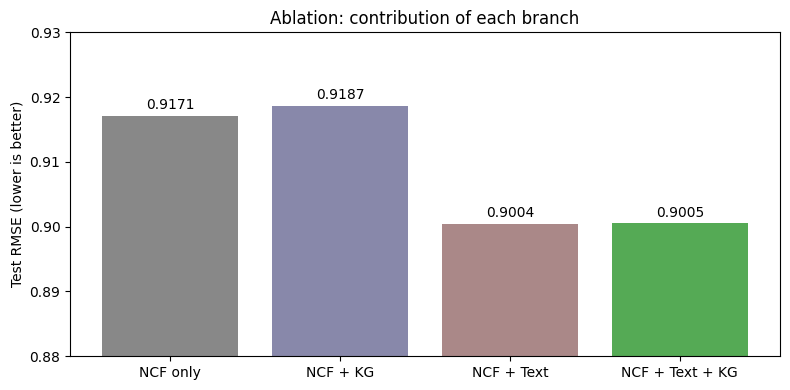

In [ ]:
import matplotlib.pyplot as plt

results = {
    'NCF only'           : test_rmse,
    'NCF + KG'           : test_rmse_kg,
    'NCF + Text'         : test_rmse2,
    'NCF + Text + KG'    : test_rmse3,
}

print(f"{'Model':<22} {'Test RMSE':>10}   {'Δ vs baseline':>15}")
print("─" * 52)
for name, rmse in results.items():
    delta = test_rmse - rmse
    print(f"{name:<22} {rmse:>10.4f}   {delta:+.4f}")

# Bar chart
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['#888', '#88a', '#a88', '#5a5'])
plt.ylabel('Test RMSE (lower is better)')
plt.title('Ablation: contribution of each branch')
plt.ylim(0.88, 0.93)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/ablation_chart.png', dpi=120)
plt.show()

In [ ]:
import json

results_summary = {
    'seed': SEED,
    'num_users': NUM_USERS,
    'num_movies': NUM_MOVIES,
    'num_ratings_total': int(len(ratings)),
    'kg_triples': int(len(triples)),
    'test_rmse': {
        'branch1_ncf'             : float(test_rmse),
        'branch_ncf_kg'           : float(test_rmse_kg),
        'branch2_ncf_text'        : float(test_rmse2),
        'branch3_ncf_text_kg'     : float(test_rmse3),
    },
    'best_model': min(results, key=results.get),
}

with open(f'{PROJECT_DIR}/results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print(json.dumps(results_summary, indent=2))

{
  "seed": 42,
  "num_users": 6040,
  "num_movies": 3657,
  "num_ratings_total": 997313,
  "kg_triples": 10125,
  "test_rmse": {
    "branch1_ncf": 0.9171001419351975,
    "branch_ncf_kg": 0.9186861973351191,
    "branch2_ncf_text": 0.900428941948834,
    "branch3_ncf_text_kg": 0.9005299556760467
  },
  "best_model": "NCF + Text"
}
